# Imports

In [82]:
import os
import time
import pandas as pd
import numpy as np
import ast
import glob
from dataclasses import dataclass
from typing import List

import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.image import imread
import nltk
from nltk import corpus, tokenize, stem
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud, STOPWORDS
from sklearn.decomposition import PCA, LatentDirichletAllocation
from sklearn.manifold import TSNE

from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans, MiniBatchKMeans

import cv2 as cv


In [8]:
init_time = time.time()

# Chargement de données

In [9]:
# !tree

In [10]:
path = "/content/drive/MyDrive/data/Flipkart/"
#path = "./data/Flipkart/"

In [11]:
data = pd.read_csv(path+'flipkart_com-ecommerce_sample_1050.csv')

# Analyse exploraoire & pretraitement des données

In [12]:
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('brown')
stop_words = set(corpus.stopwords.words('english'))

wordnet_map = {"N":corpus.wordnet.NOUN, "V":corpus.wordnet.VERB, "J":corpus.wordnet.ADJ, "R":corpus.wordnet.ADV}

def tokenize_document(document):
    # Transformer le document en lowercase
    document = document.lower().strip()

    # Tokeniser le document
    tokens = tokenize.word_tokenize(document)

    # Supprimer les stop-words
    tokens = [token for token in tokens if token not in stop_words]

    # Suprimer les token ayant moins de trois lettre
    tokens = [token for token in tokens if len(token) > 2]

    # Supprimer les caractéres non alpha numerique
    tokens = [token for token in tokens if token.isalpha()]

    return tokens


def stemming_document(tokenized_doc):

    stemmer = nltk.PorterStemmer()

    stems = [stemmer.stem(t) for t in tokenized_doc]

    return stems




train_sents = corpus.brown.tagged_sents(categories='news')
t0 = nltk.DefaultTagger('NN')
t1 = nltk.UnigramTagger(train_sents, backoff=t0)
t2 = nltk.BigramTagger(train_sents, backoff=t1)

def pos_tag_wordnet(text, pos_tag_type="pos_tag"):
    """
        Create pos_tag with wordnet format
    """
    pos_tagged_text = t2.tag(text)

    pos_tagged_text = [(word, wordnet_map.get(pos_tag[0])) if pos_tag[0] in wordnet_map.keys() else (word, corpus.wordnet.NOUN) for (word, pos_tag) in pos_tagged_text ]
    return pos_tagged_text


def lemmatize_word(text):
    """
        Lemmatize the tokenized words
    """

    lemmatizer = stem.WordNetLemmatizer()
    lemma = [lemmatizer.lemmatize(word, tag) for word, tag in text]
    return lemma

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.


In [13]:
data.head()

,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications
0,55b85ea15a1536d46b7190ad6fff8ce7,2016-04-30 03:22:56 +0000,http://www.flipkart.com/elegance-polyester-mul...,Elegance Polyester Multicolor Abstract Eyelet ...,"[""Home Furnishing >> Curtains & Accessories >>...",CRNEG7BKMFFYHQ8Z,1899.0,899.0,55b85ea15a1536d46b7190ad6fff8ce7.jpg,False,Key Features of Elegance Polyester Multicolor ...,No rating available,No rating available,Elegance,"{""product_specification""=>[{""key""=>""Brand"", ""v..."
1,7b72c92c2f6c40268628ec5f14c6d590,2016-04-30 03:22:56 +0000,http://www.flipkart.com/sathiyas-cotton-bath-t...,Sathiyas Cotton Bath Towel,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",BTWEGFZHGBXPHZUH,600.0,449.0,7b72c92c2f6c40268628ec5f14c6d590.jpg,False,Specifications of Sathiyas Cotton Bath Towel (...,No rating available,No rating available,Sathiyas,"{""product_specification""=>[{""key""=>""Machine Wa..."
2,64d5d4a258243731dc7bbb1eef49ad74,2016-04-30 03:22:56 +0000,http://www.flipkart.com/eurospa-cotton-terry-f...,Eurospa Cotton Terry Face Towel Set,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",BTWEG6SHXTDB2A2Y,NaN,NaN,64d5d4a258243731dc7bbb1eef49ad74.jpg,False,Key Features of Eurospa Cotton Terry Face Towe...,No rating available,No rating available,Eurospa,"{""product_specification""=>[{""key""=>""Material"",..."
3,d4684dcdc759dd9cdf41504698d737d8,2016-06-20 08:49:52 +0000,http://www.flipkart.com/santosh-royal-fashion-...,SANTOSH ROYAL FASHION Cotton Printed King size...,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",BDSEJT9UQWHDUBH4,2699.0,1299.0,d4684dcdc759dd9cdf41504698d737d8.jpg,False,Key Features of SANTOSH ROYAL FASHION Cotton P...,No rating available,No rating available,SANTOSH ROYAL FASHION,"{""product_specification""=>[{""key""=>""Brand"", ""v..."
4,6325b6870c54cd47be6ebfbffa620ec7,2016-06-20 08:49:52 +0000,http://www.flipkart.com/jaipur-print-cotton-fl...,Jaipur Print Cotton Floral King sized Double B...,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",BDSEJTHNGWVGWWQU,2599.0,698.0,6325b6870c54cd47be6ebfbffa620ec7.jpg,False,Key Features of Jaipur Print Cotton Floral Kin...,No rating available,No rating available,Jaipur Print,"{""product_specification""=>[{""key""=>""Machine Wa..."


In [14]:
data.tail()

,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications
1045,958f54f4c46b53c8a0a9b8167d9140bc,2015-12-01 10:15:43 +0000,http://www.flipkart.com/oren-empower-extra-lar...,Oren Empower Extra Large Self Adhesive Sticker,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",STIE88ZGTX65GH4V,1399.0,999.0,958f54f4c46b53c8a0a9b8167d9140bc.jpg,False,Oren Empower Extra Large Self Adhesive Sticker...,No rating available,No rating available,Oren Empower,"{""product_specification""=>[{""key""=>""Number of ..."
1046,fd6cbcc22efb6b761bd564c28928483c,2015-12-01 10:15:43 +0000,http://www.flipkart.com/wallmantra-large-vinyl...,Wallmantra Large Vinyl Sticker Sticker,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",STIEC889ZD5GDCVQ,4930.0,1896.0,fd6cbcc22efb6b761bd564c28928483c.jpg,False,Wallmantra Large Vinyl Sticker Sticker (Pack o...,No rating available,No rating available,Wallmantra,"{""product_specification""=>[{""key""=>""Number of ..."
1047,5912e037d12774bb73a2048f35a00009,2015-12-01 10:15:43 +0000,http://www.flipkart.com/uberlyfe-extra-large-p...,Uberlyfe Extra Large Pigmented Polyvinyl Films...,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",STIE5UVGW2JWVWCT,4500.0,1449.0,5912e037d12774bb73a2048f35a00009.jpg,False,Buy Uberlyfe Extra Large Pigmented Polyvinyl F...,No rating available,No rating available,Uberlyfe,"{""product_specification""=>[{""key""=>""Number of ..."
1048,c3edc504d1b4f0ba6224fa53a43a7ad6,2015-12-01 10:15:43 +0000,http://www.flipkart.com/wallmantra-medium-viny...,Wallmantra Medium Vinyl Sticker Sticker,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",STIEC889ZGFD3RCE,3465.0,1333.0,c3edc504d1b4f0ba6224fa53a43a7ad6.jpg,False,Buy Wallmantra Medium Vinyl Sticker Sticker fo...,No rating available,No rating available,Wallmantra,"{""product_specification""=>[{""key""=>""Number of ..."
1049,f2f027ad6a6df617c9f125173da71e44,2015-12-01 10:15:43 +0000,http://www.flipkart.com/uberlyfe-large-vinyl-s...,Uberlyfe Large Vinyl Sticker,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",STIE2ZEPACRQJKH7,1190.0,595.0,f2f027ad6a6df617c9f125173da71e44.jpg,False,Buy Uberlyfe Large Vinyl Sticker for Rs.595 on...,4,4,Uberlyfe,"{""product_specification""=>[{""key""=>""Sales Pack..."


In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   uniq_id                  1050 non-null   object 
 1   crawl_timestamp          1050 non-null   object 
 2   product_url              1050 non-null   object 
 3   product_name             1050 non-null   object 
 4   product_category_tree    1050 non-null   object 
 5   pid                      1050 non-null   object 
 6   retail_price             1049 non-null   float64
 7   discounted_price         1049 non-null   float64
 8   image                    1050 non-null   object 
 9   is_FK_Advantage_product  1050 non-null   bool   
 10  description              1050 non-null   object 
 11  product_rating           1050 non-null   object 
 12  overall_rating           1050 non-null   object 
 13  brand                    712 non-null    object 
 14  product_specifications  

In [16]:
data.dtypes.value_counts()

,count
object,12
float64,2
bool,1


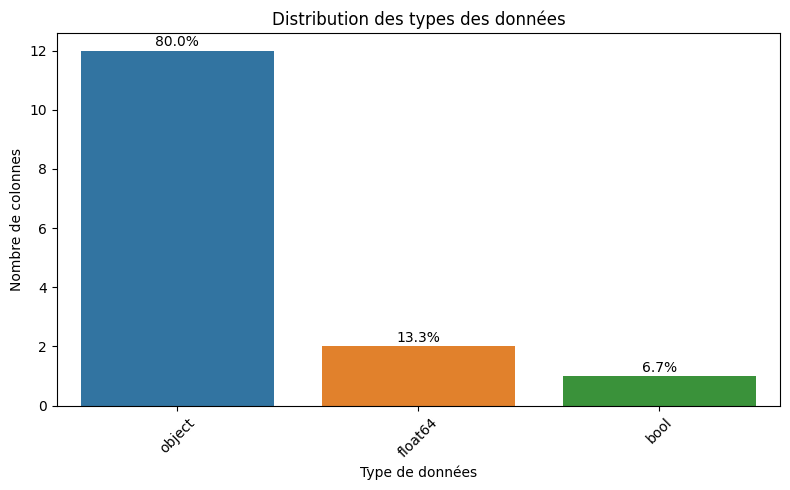

In [17]:
dtype_counts = data.dtypes.value_counts().reset_index()
dtype_counts.columns = ['dtype', 'count']

total = dtype_counts['count'].sum()
dtype_counts['percent'] = (dtype_counts['count'] / total * 100).round(1)

plt.figure(figsize=(8, 5))
sns.barplot(data=dtype_counts, x='dtype', y='count', hue='dtype')

for index, row in dtype_counts.iterrows():
    plt.text(x=index, y=row['count'] + total * 0.01, s=f"{row['percent']}%", ha='center')

plt.title("Distribution des types des données")
plt.xlabel("Type de données")
plt.ylabel("Nombre de colonnes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
data.nunique()

,0
uniq_id,1050
crawl_timestamp,149
product_url,1050
product_name,1050
product_category_tree,642
pid,1050
retail_price,354
discounted_price,424
image,1050
is_FK_Advantage_product,2


## | Documents manquants et/ou dupliqués

In [19]:
missing_values = data.isna()
display(missing_values.sum())

,0
uniq_id,0
crawl_timestamp,0
product_url,0
product_name,0
product_category_tree,0
pid,0
retail_price,1
discounted_price,1
image,0
is_FK_Advantage_product,0


In [20]:
# Le total de valeurs manquantes

total_missing_values = missing_values.sum().sum()
print(f"Le total de valeurs manquante est de: {total_missing_values}, soit un pourcenatge de {100*(total_missing_values / data.size)}" )
labels = ['Valeurs manquantes', 'Valeurs non manquantes']

values = [total_missing_values, data.size - total_missing_values]


Le total de valeurs manquante est de: 341, soit un pourcenatge de 2.165079365079365


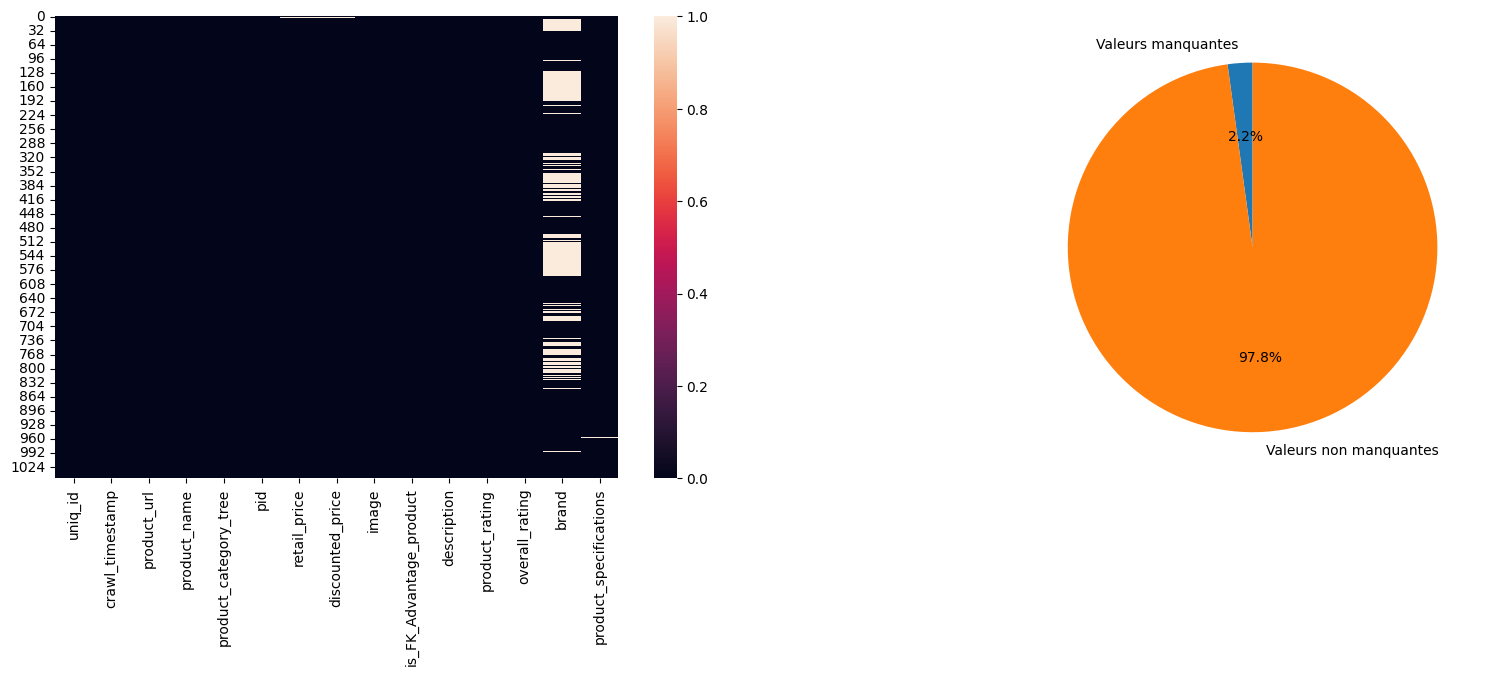

In [21]:
fig = plt.figure(figsize=(20, 6))
ax = fig.add_subplot(121)
sns.heatmap(missing_values)

ax = fig.add_subplot(122)
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90)

plt.show()

In [22]:
data.duplicated(subset='uniq_id').sum()

np.int64(0)

## | variable: product_category_tree

In [23]:
data.product_category_tree.describe()

,product_category_tree
count,1050
unique,642
top,"[""Home Furnishing >> Bed Linen >> Blankets, Qu..."
freq,56


In [24]:
data.product_category_tree[0]

'["Home Furnishing >> Curtains & Accessories >> Curtains >> Elegance Polyester Multicolor Abstract Eyelet Do..."]'

On observe que la variable product_category_tree contient une liste de ctégorie pour chaque produit.

Nous allons explorer les categories.

In [25]:
def get_len_category(doc):
    doc = doc.replace('[', '').replace(']', '').strip('"')
    categories = doc.split(">>")
    categories = [cat.strip() for cat in categories]
    return len(set(categories))


def get_category_level(doc, level=0):
    doc = doc.replace('[', '').replace(']', '').strip('"')
    categories = doc.split(">>")
    categories = [cat.strip() for cat in categories]
    if level >= len(categories):
        return None
    return categories[level]


tmp = data.product_category_tree.apply(get_len_category).to_frame()

In [26]:
tmp['level_1'] = data.product_category_tree.apply(get_category_level, level=0)
tmp['level_2'] = data.product_category_tree.apply(get_category_level, level=1)
tmp['level_3'] = data.product_category_tree.apply(get_category_level, level=2)
tmp['level_4'] = data.product_category_tree.apply(get_category_level, level=3)
tmp['level_5'] = data.product_category_tree.apply(get_category_level, level=4)
tmp['level_6'] = data.product_category_tree.apply(get_category_level, level=5)
tmp['level_7'] = data.product_category_tree.apply(get_category_level, level=6)

In [27]:
tmp.describe()

,product_category_tree
count,1050.000000
mean,4.203810
std,1.157058
min,2.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,7.000000


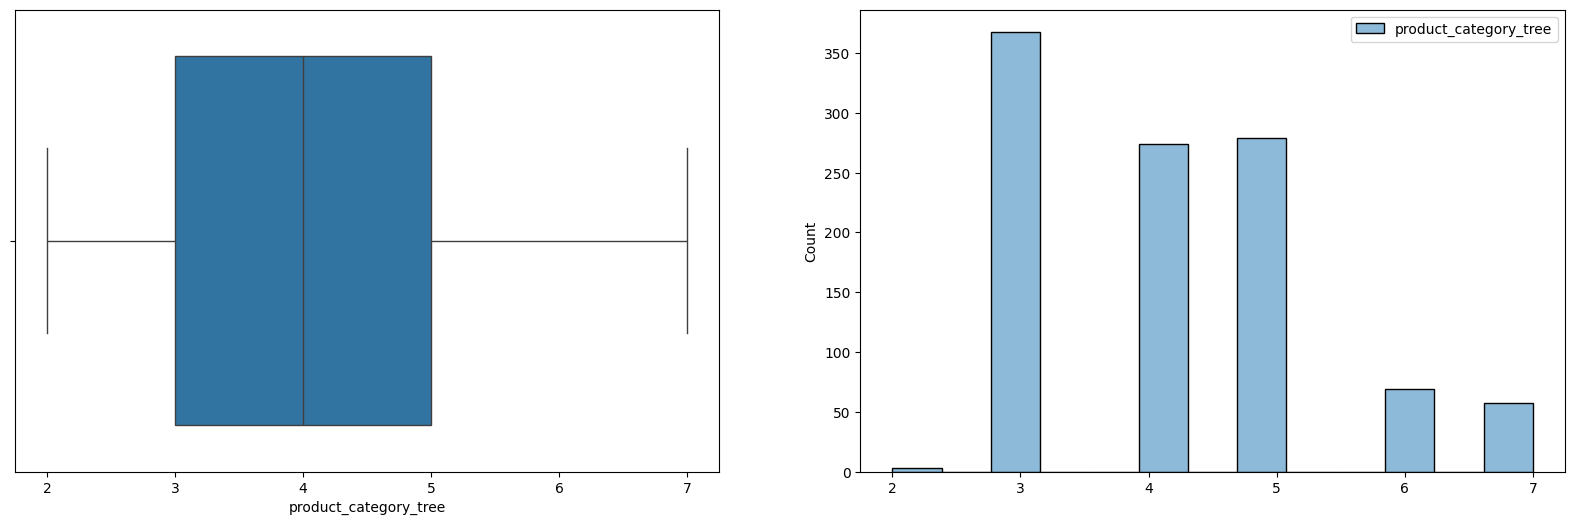

In [28]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(20, 6))
sns.boxplot(x='product_category_tree', data=tmp, ax=ax0)
sns.histplot(tmp, ax=ax1)
plt.show()

In [29]:
level_counts = pd.DataFrame({
    'level': ['1', '2', '3', '4', '5', '6', '7'],
    'nb_category': [
        tmp['level_1'].nunique(),
        tmp['level_2'].nunique(),
        tmp['level_3'].nunique(),
        tmp['level_4'].nunique(),
        tmp['level_5'].nunique(),
        tmp['level_6'].nunique(),
        tmp['level_7'].nunique()
    ]
})

level_counts

,level,nb_category
0,1,7
1,2,62
2,3,241
3,4,349
4,5,297
5,6,117
6,7,57


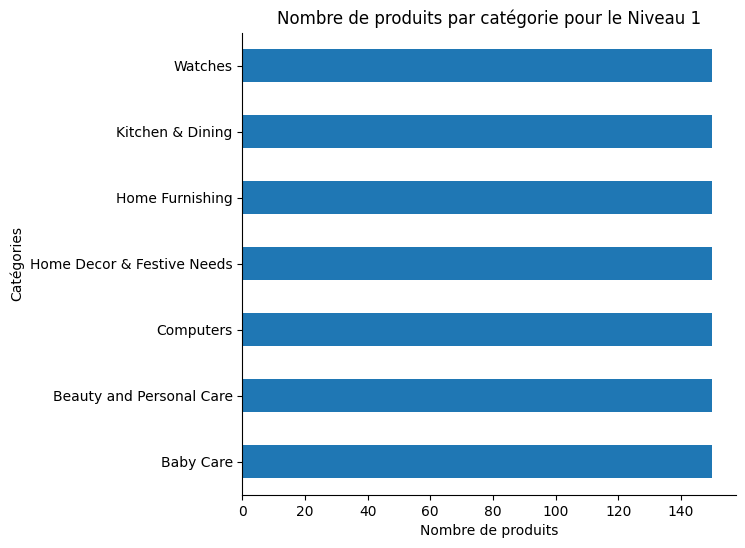

In [30]:
fig = plt.figure(figsize=(14, 6))
ax = fig.add_subplot(121)
tmp.groupby('level_1').size().plot(kind='barh')
plt.xlabel('Nombre de produits')
plt.ylabel('Catégories')
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.title('Nombre de produits par catégorie pour le Niveau 1')
plt.show()

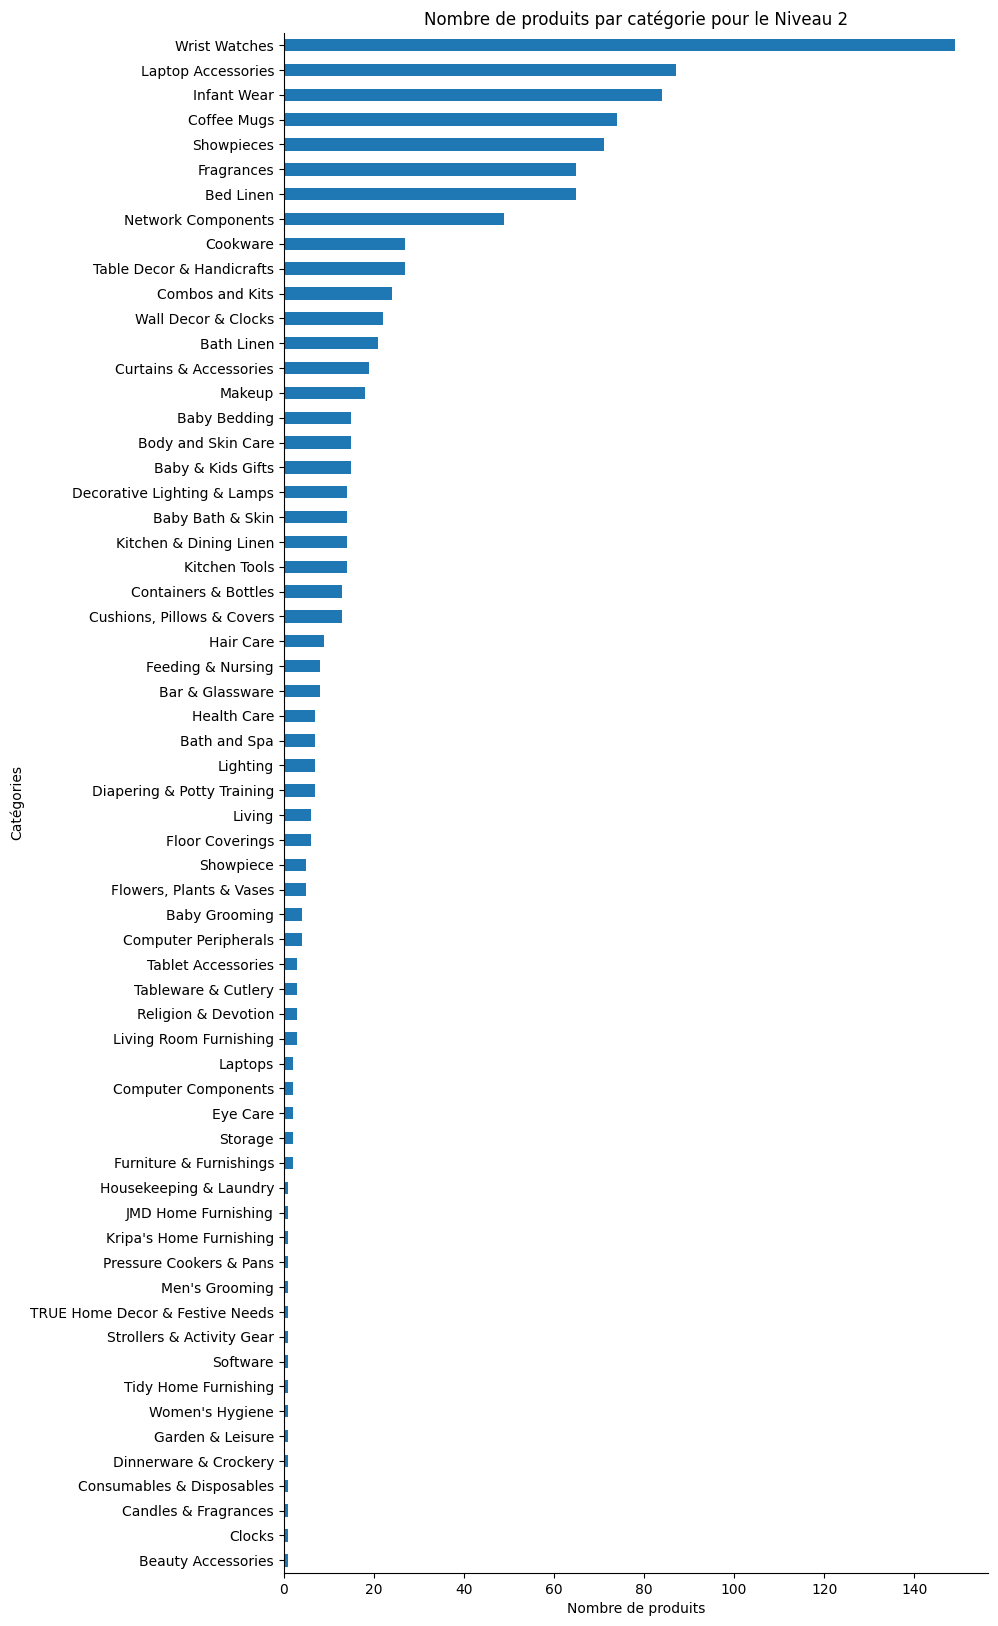

In [31]:
fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(121)
tmp.groupby('level_2').size().sort_values().plot(kind='barh')
plt.xlabel('Nombre de produits')
plt.ylabel('Catégories')
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.title('Nombre de produits par catégorie pour le Niveau 2')
plt.show()

Un produit à au minimum deux niveaux categories et au plus 7

In [32]:
tmp.value_counts()

product_category_tree  level_1                   level_2      level_3                level_4                 level_5                level_6                              level_7                                            
7                      Baby Care                 Infant Wear  Baby Boys' Clothes     Accessories             Caps                   florence9 Caps                       florence9 baby cap red checks Cap                      1
                                                                                     Bodysuits & Sleepsuits  Bodysuits              FS Mini Klub Bodysuits               FS Mini Klub Baby Boy's Bodysuit                       1
                                                                                                                                    You Got Plan B Bodysuits             You Got Plan B Baby Boy's, Baby Girl's Romper          1
                                                                                                                                    chota packet Bodysuits               chota packet Baby Boy's, Baby Girl's Bodysuit          1
                                                                                                             Sleepsuits             FS Mini Klub Sleepsuits              FS Mini Klub Baby Boy's Sleepsuit                      1
                                                                                                                                    Toffyhouse Sleepsuits                Toffyhouse Baby Boy's Sleepsuit                        1
                                                                                     Dungarees & Jumpsuits   Dungarees              Babeezworld Dungarees                Babeezworld Baby Boy's Romper                          1
                                                                                                                                    Kandyfloss Dungarees                 Kandyfloss Baby Boy's, Baby Girl's Romper              1
                                                                                                                                    cherry crumble california Dungarees  cherry crumble california Baby Boy's Dungaree          1
                                                                                     Innerwear & Sleepwear   Bloomers & Drawers     Esteem Bloomers & Drawers            Esteem Baby Boy's Drawer                               1
                                                                                     Shorts & Trousers       Shorts                 FS Mini Klub Shorts                  FS Mini Klub Printed Baby Boy's Multicolor Basic...    1
                                                                                                                                    Lilliput Shorts                      Lilliput Solid Baby Boy's Blue Cargo Shorts            1
                                                                                                             Track Pants            Shaun Track Pants                    Shaun Printed Baby Boy's Yellow, Grey, Black Tra...    1
                                                                                                                                                                         Shaun Solid Baby Boy's Grey, Dark Blue Track Pants     1
                                                                                     Suits and Blazers       Blazers                Oxolloxo Blazers                     Oxolloxo Solid Single Breasted Casual Women's Bl...    1
                                                                                     Winter & Seasonal Wear  Jackets                Upside Down Jackets                  Upside Down Sleeveless Applique Baby Girl's, Bab...    1
                                                              Baby Girls' Clothes    Accessories             Hats                   Portia Hats                    

In [33]:
len(tmp.level_1.unique())

7

In [34]:
data['category'] = data['product_category_tree'].str.extract('([a-zA-Z ]+)', expand=False).str.strip()

In [35]:
data.category.value_counts()

,count
category,
Home Furnishing,150
Baby Care,150
Watches,150
Home Decor,150
Kitchen,150
Beauty and Personal Care,150
Computers,150


In [36]:
p = data.loc[data.category == 'Home Furnishing', ]
p.iloc[0]['uniq_id']

'55b85ea15a1536d46b7190ad6fff8ce7'

Category: Home Furnishing


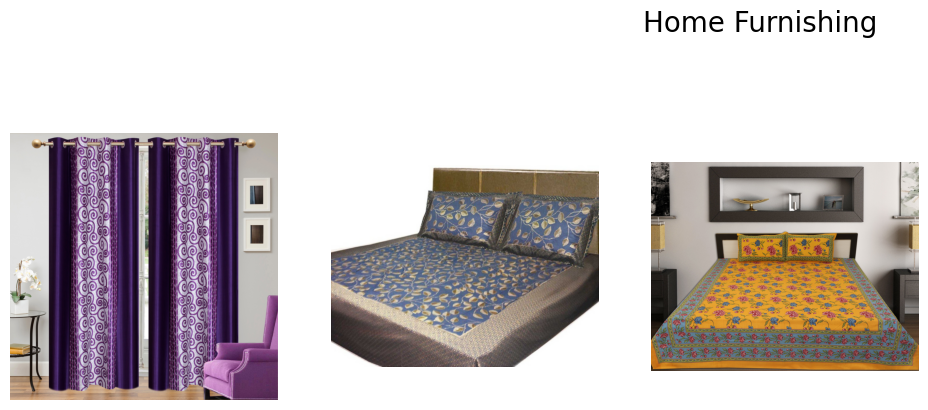

Category: Baby Care


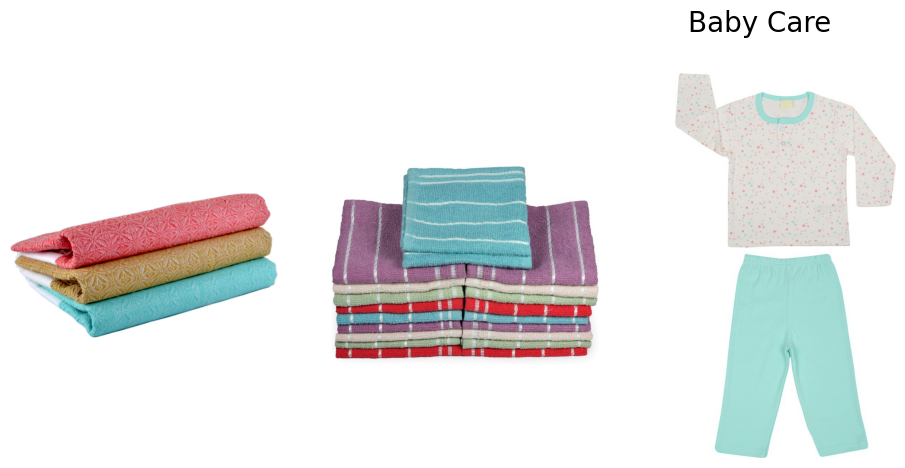

Category: Watches


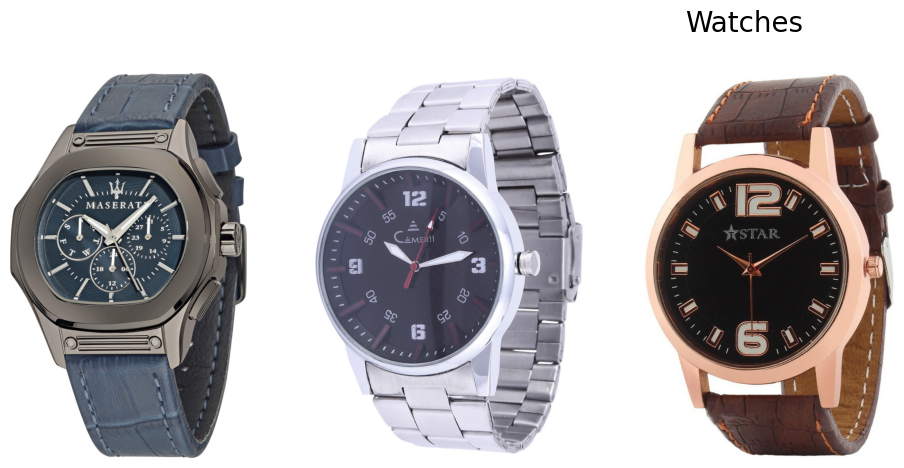

Category: Home Decor


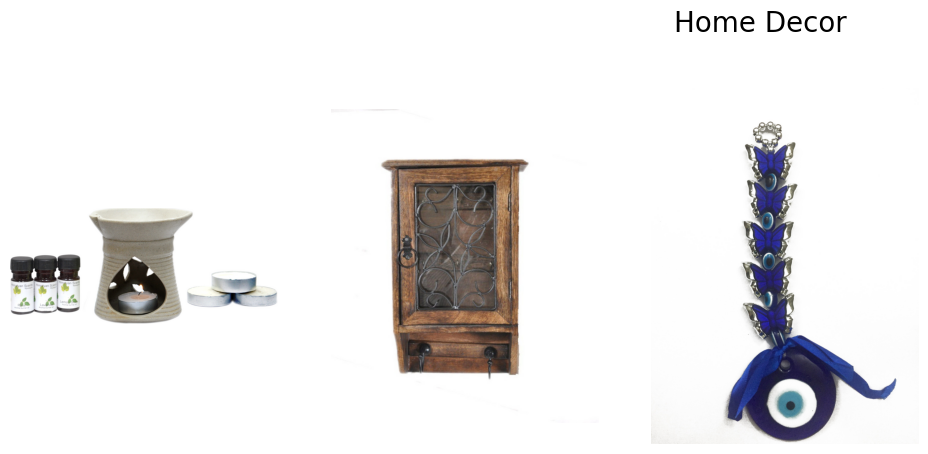

Category: Kitchen


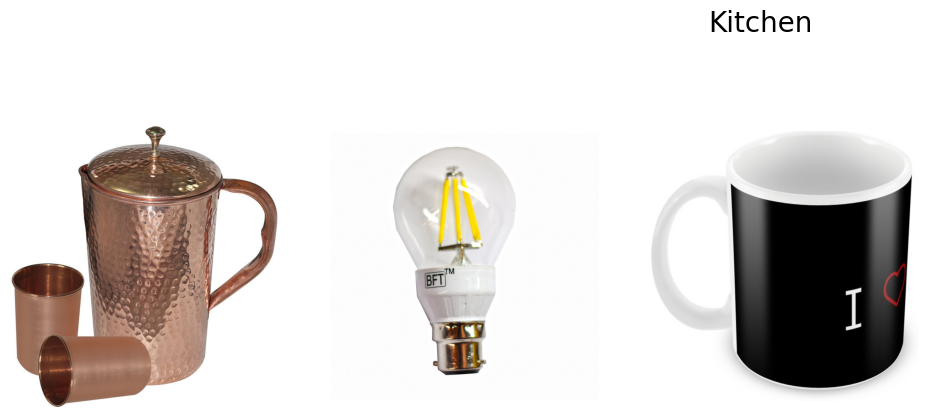

Category: Beauty and Personal Care


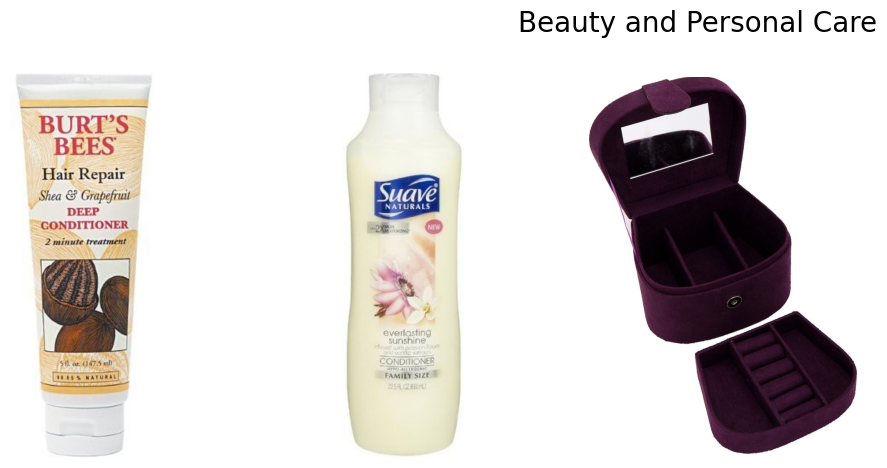

Category: Computers


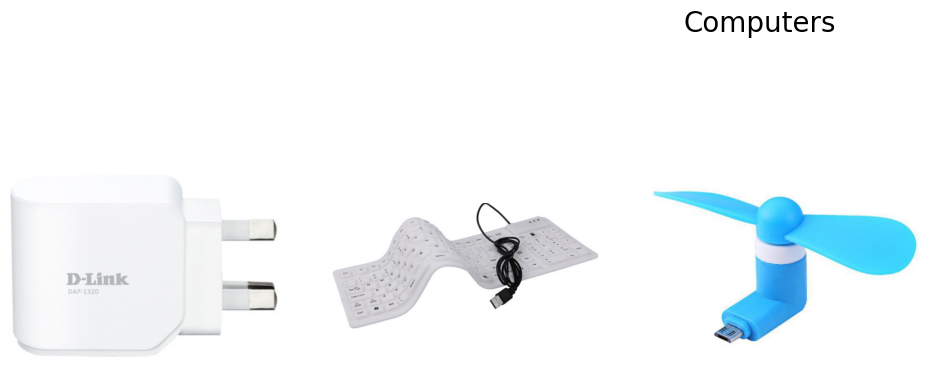

CPU times: user 3.26 s, sys: 178 ms, total: 3.44 s
Wall time: 13.2 s


In [37]:
%%time
# Affichage image de categorie
for i, category in enumerate(data.category.unique()):
    products = data.loc[data.category == category, ]
    fig = plt.figure(figsize = (20, 5))
    fig.suptitle(category, fontsize=20, va='center')
    for j in range(3):
        p = products.iloc[j]
        plt.subplot(150 + 1 + j)
        filename = path+"Images/"+p['uniq_id']+".jpg"
        image = imread(filename)
        plt.imshow(image)
        plt.axis('off')
    print(f"Category: {category}")
    #plt.suptitle(category, x=0.5, y=0.5)
    plt.show()

## | variable: description

In [38]:
data.head(5)

,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications,category
0,55b85ea15a1536d46b7190ad6fff8ce7,2016-04-30 03:22:56 +0000,http://www.flipkart.com/elegance-polyester-mul...,Elegance Polyester Multicolor Abstract Eyelet ...,"[""Home Furnishing >> Curtains & Accessories >>...",CRNEG7BKMFFYHQ8Z,1899.0,899.0,55b85ea15a1536d46b7190ad6fff8ce7.jpg,False,Key Features of Elegance Polyester Multicolor ...,No rating available,No rating available,Elegance,"{""product_specification""=>[{""key""=>""Brand"", ""v...",Home Furnishing
1,7b72c92c2f6c40268628ec5f14c6d590,2016-04-30 03:22:56 +0000,http://www.flipkart.com/sathiyas-cotton-bath-t...,Sathiyas Cotton Bath Towel,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",BTWEGFZHGBXPHZUH,600.0,449.0,7b72c92c2f6c40268628ec5f14c6d590.jpg,False,Specifications of Sathiyas Cotton Bath Towel (...,No rating available,No rating available,Sathiyas,"{""product_specification""=>[{""key""=>""Machine Wa...",Baby Care
2,64d5d4a258243731dc7bbb1eef49ad74,2016-04-30 03:22:56 +0000,http://www.flipkart.com/eurospa-cotton-terry-f...,Eurospa Cotton Terry Face Towel Set,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",BTWEG6SHXTDB2A2Y,NaN,NaN,64d5d4a258243731dc7bbb1eef49ad74.jpg,False,Key Features of Eurospa Cotton Terry Face Towe...,No rating available,No rating available,Eurospa,"{""product_specification""=>[{""key""=>""Material"",...",Baby Care
3,d4684dcdc759dd9cdf41504698d737d8,2016-06-20 08:49:52 +0000,http://www.flipkart.com/santosh-royal-fashion-...,SANTOSH ROYAL FASHION Cotton Printed King size...,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",BDSEJT9UQWHDUBH4,2699.0,1299.0,d4684dcdc759dd9cdf41504698d737d8.jpg,False,Key Features of SANTOSH ROYAL FASHION Cotton P...,No rating available,No rating available,SANTOSH ROYAL FASHION,"{""product_specification""=>[{""key""=>""Brand"", ""v...",Home Furnishing
4,6325b6870c54cd47be6ebfbffa620ec7,2016-06-20 08:49:52 +0000,http://www.flipkart.com/jaipur-print-cotton-fl...,Jaipur Print Cotton Floral King sized Double B...,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",BDSEJTHNGWVGWWQU,2599.0,698.0,6325b6870c54cd47be6ebfbffa620ec7.jpg,False,Key Features of Jaipur Print Cotton Floral Kin...,No rating available,No rating available,Jaipur Print,"{""product_specification""=>[{""key""=>""Machine Wa...",Home Furnishing


In [39]:
data.description.info()

<class 'pandas.core.series.Series'>
RangeIndex: 1050 entries, 0 to 1049
Series name: description
Non-Null Count  Dtype 
--------------  ----- 
1050 non-null   object
dtypes: object(1)
memory usage: 8.3+ KB


In [40]:
data.description.describe()

,description
count,1050
unique,1050
top,Buy Uberlyfe Large Vinyl Sticker for Rs.595 on...
freq,1


### Tokenization

In [41]:
data['tokenized_description'] = data.description.apply(tokenize_document)

In [42]:
data.tokenized_description

,tokenized_description
0,"[key, features, elegance, polyester, multicolo..."
1,"[specifications, sathiyas, cotton, bath, towel..."
2,"[key, features, eurospa, cotton, terry, face, ..."
3,"[key, features, santosh, royal, fashion, cotto..."
4,"[key, features, jaipur, print, cotton, floral,..."
...,...
1045,"[oren, empower, extra, large, self, adhesive, ..."
1046,"[wallmantra, large, vinyl, sticker, sticker, p..."
1047,"[buy, uberlyfe, extra, large, pigmented, polyv..."
1048,"[buy, wallmantra, medium, vinyl, sticker, stic..."


### Stemming

In [43]:
data['stemmed_description'] = data.tokenized_description.apply(stemming_document)

In [44]:
data.stemmed_description

,stemmed_description
0,"[key, featur, eleg, polyest, multicolor, abstr..."
1,"[specif, sathiya, cotton, bath, towel, bath, t..."
2,"[key, featur, eurospa, cotton, terri, face, to..."
3,"[key, featur, santosh, royal, fashion, cotton,..."
4,"[key, featur, jaipur, print, cotton, floral, k..."
...,...
1045,"[oren, empow, extra, larg, self, adhes, sticke..."
1046,"[wallmantra, larg, vinyl, sticker, sticker, pa..."
1047,"[buy, uberlyf, extra, larg, pigment, polyvinyl..."
1048,"[buy, wallmantra, medium, vinyl, sticker, stic..."


### Part of Speech Tagging (POS Tagging)

In [45]:
pos_tag_wordnet(data.tokenized_description[2])[:10]

[('key', 'n'),
 ('features', 'v'),
 ('eurospa', 'n'),
 ('cotton', 'n'),
 ('terry', 'n'),
 ('face', 'v'),
 ('towel', 'n'),
 ('set', 'v'),
 ('size', 'n'),
 ('small', 'a')]

In [46]:
data['combined_postag_wnet'] = data.tokenized_description.apply(lambda x: pos_tag_wordnet(x))

In [47]:
data.combined_postag_wnet

,combined_postag_wnet
0,"[(key, n), (features, v), (elegance, n), (poly..."
1,"[(specifications, n), (sathiyas, n), (cotton, ..."
2,"[(key, n), (features, v), (eurospa, n), (cotto..."
3,"[(key, n), (features, v), (santosh, n), (royal..."
4,"[(key, n), (features, v), (jaipur, n), (print,..."
...,...
1045,"[(oren, n), (empower, n), (extra, a), (large, ..."
1046,"[(wallmantra, n), (large, a), (vinyl, n), (sti..."
1047,"[(buy, v), (uberlyfe, n), (extra, a), (large, ..."
1048,"[(buy, v), (wallmantra, n), (medium, n), (viny..."


### Lemmatization

In [48]:
data['lemmatized_description'] = data.combined_postag_wnet.apply(lemmatize_word)
data['lemmatized_description_text'] = [' '.join(map(str, l)) for l in data['lemmatized_description']]

In [49]:
data['lemmatized_description_text']

,lemmatized_description_text
0,key feature elegance polyester multicolor abst...
1,specification sathiyas cotton bath towel bath ...
2,key feature eurospa cotton terry face towel se...
3,key feature santosh royal fashion cotton print...
4,key feature jaipur print cotton floral king si...
...,...
1045,oren empower extra large self adhesive sticker...
1046,wallmantra large vinyl sticker sticker pack pr...
1047,buy uberlyfe extra large pigmented polyvinyl f...
1048,buy wallmantra medium vinyl sticker sticker on...


In [50]:
# Comparaison entre le texte original et le texte lemmatisé
display(data["description"][0])
print("----"*10)
display(data["lemmatized_description_text"][0])

'Key Features of Elegance Polyester Multicolor Abstract Eyelet Door Curtain Floral Curtain,Elegance Polyester Multicolor Abstract Eyelet Door Curtain (213 cm in Height, Pack of 2) Price: Rs. 899 This curtain enhances the look of the interiors.This curtain is made from 100% high quality polyester fabric.It features an eyelet style stitch with Metal Ring.It makes the room environment romantic and loving.This curtain is ant- wrinkle and anti shrinkage and have elegant apparance.Give your home a bright and modernistic appeal with these designs. The surreal attention is sure to steal hearts. These contemporary eyelet and valance curtains slide smoothly so when you draw them apart first thing in the morning to welcome the bright sun rays you want to wish good morning to the whole world and when you draw them close in the evening, you create the most special moments of joyous beauty given by the soothing prints. Bring home the elegant curtain that softly filters light in your room so that you

----------------------------------------


'key feature elegance polyester multicolor abstract eyelet door curtain floral curtain elegance polyester multicolor abstract eyelet door curtain height pack price curtain enhances look curtain make high quality polyester feature eyelet style stitch metal make room environment romantic curtain wrinkle anti shrinkage elegant home bright modernistic appeal design surreal attention sure steal heart contemporary eyelet valance curtain slide smoothly draw apart first thing morning welcome bright sun ray want wish good morning whole world draw close evening create special moment joyous beauty give soothing print bring home elegant curtain softly filter light room get right amount specification elegance polyester multicolor abstract eyelet door curtain height pack general brand elegance design door type eyelet model name abstract polyester door curtain set model color multicolor dimension length box number content sale package pack sale package curtain body design material polyester'

## | variable: product_name

In [51]:
data.product_name.info()

<class 'pandas.core.series.Series'>
RangeIndex: 1050 entries, 0 to 1049
Series name: product_name
Non-Null Count  Dtype 
--------------  ----- 
1050 non-null   object
dtypes: object(1)
memory usage: 8.3+ KB


In [52]:
data.product_name.head()

,product_name
0,Elegance Polyester Multicolor Abstract Eyelet ...
1,Sathiyas Cotton Bath Towel
2,Eurospa Cotton Terry Face Towel Set
3,SANTOSH ROYAL FASHION Cotton Printed King size...
4,Jaipur Print Cotton Floral King sized Double B...


### Tokenisation

In [53]:
data['tokenized_product_name'] = data.product_name.apply(tokenize_document)

In [54]:
data.tokenized_product_name

,tokenized_product_name
0,"[elegance, polyester, multicolor, abstract, ey..."
1,"[sathiyas, cotton, bath, towel]"
2,"[eurospa, cotton, terry, face, towel, set]"
3,"[santosh, royal, fashion, cotton, printed, kin..."
4,"[jaipur, print, cotton, floral, king, sized, d..."
...,...
1045,"[oren, empower, extra, large, self, adhesive, ..."
1046,"[wallmantra, large, vinyl, sticker, sticker]"
1047,"[uberlyfe, extra, large, pigmented, polyvinyl,..."
1048,"[wallmantra, medium, vinyl, sticker, sticker]"


### Part of Speech Tagging (POS Tagging)

In [55]:
pos_tag_wordnet(data.tokenized_product_name[2])[:10]

[('eurospa', 'n'),
 ('cotton', 'n'),
 ('terry', 'n'),
 ('face', 'v'),
 ('towel', 'n'),
 ('set', 'v')]

In [56]:
data['combined_postag_wnet_product_name'] = data.tokenized_product_name.apply(lambda x: pos_tag_wordnet(x))

In [57]:
data.combined_postag_wnet_product_name

,combined_postag_wnet_product_name
0,"[(elegance, n), (polyester, n), (multicolor, n..."
1,"[(sathiyas, n), (cotton, n), (bath, n), (towel..."
2,"[(eurospa, n), (cotton, n), (terry, n), (face,..."
3,"[(santosh, n), (royal, a), (fashion, n), (cott..."
4,"[(jaipur, n), (print, n), (cotton, n), (floral..."
...,...
1045,"[(oren, n), (empower, n), (extra, a), (large, ..."
1046,"[(wallmantra, n), (large, a), (vinyl, n), (sti..."
1047,"[(uberlyfe, n), (extra, a), (large, a), (pigme..."
1048,"[(wallmantra, n), (medium, n), (vinyl, n), (st..."


### Lemmatization

In [58]:
data['lemmatized_product_name'] = data.combined_postag_wnet_product_name.apply(lemmatize_word)
data['lemmatized_product_name_text'] = [' '.join(map(str, l)) for l in data['lemmatized_product_name']]

In [59]:
data.lemmatized_product_name_text

,lemmatized_product_name_text
0,elegance polyester multicolor abstract eyelet ...
1,sathiyas cotton bath towel
2,eurospa cotton terry face towel set
3,santosh royal fashion cotton print king sized ...
4,jaipur print cotton floral king sized double b...
...,...
1045,oren empower extra large self adhesive sticker
1046,wallmantra large vinyl sticker sticker
1047,uberlyfe extra large pigmented polyvinyl film ...
1048,wallmantra medium vinyl sticker sticker


In [60]:
# Comparaison entre le texte original et le texte lemmatisé
display(data["product_name"][3])
print("----"*10)
display(data["lemmatized_product_name_text"][3])

'SANTOSH ROYAL FASHION Cotton Printed King sized Double Bedsheet'

----------------------------------------


'santosh royal fashion cotton print king sized double bedsheet'

## Création des corpus

In [61]:
# Ce corpus contient uniquement les documents provenant de la variable description
corpus_1 = data.lemmatized_description_text.tolist()

# Ce corpus contient la combinaison des documents (product_name et description)
corpus_2 = (data.lemmatized_product_name_text + data.lemmatized_description_text).tolist()

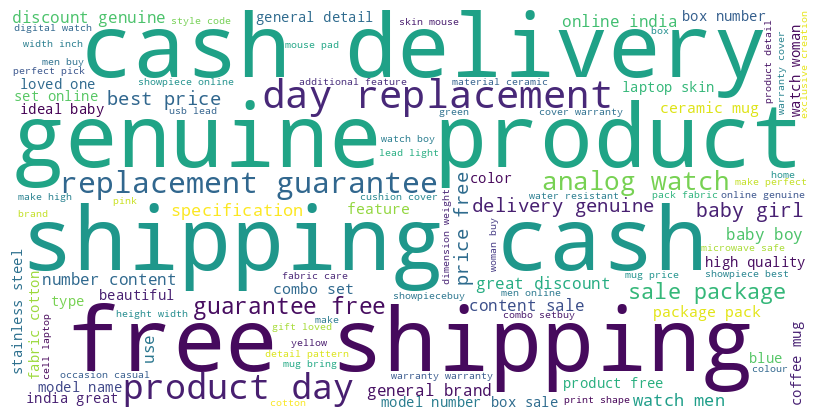

In [62]:
text_2 = " ".join(corpus_2)

fig = plt.figure(figsize=(8, 8), facecolor=None)

wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      stopwords=set(STOPWORDS),
                      min_font_size=10).generate(text_2)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

# Extraction des caracteristiques

## Texts

In [63]:
def pca_dimensions(data, n=2):
  pca = PCA(n_components=n)
  pca.fit(data)
  return pca, pca.transform(data)

def tsne_visu_fct(X_tsne, y_cat_num, labels, ARI, title):
    fig = plt.figure(figsize=(15,6))
    fig.suptitle(title)
    ax = fig.add_subplot(121)

    scatter = ax.scatter(X_tsne[:,0],X_tsne[:,1], c=y_cat_num, cmap='Set1')
    ax.legend(handles=scatter.legend_elements()[0], labels=set(y_cat_num), loc="best", title="Categorie")
    plt.title(f"Représentation des produits par catégories réelles")

    ax = fig.add_subplot(122)
    scatter = ax.scatter(X_tsne[:,0],X_tsne[:,1], c=labels, cmap='Set1')
    ax.legend(handles=scatter.legend_elements()[0], labels=set(labels), loc="best", title="Clusters")
    plt.title(f"Représentation des produits par clusters => ARI={ARI}")
    plt.show()

In [64]:
@dataclass
class TFIDFVector:
  vect: TfidfVectorizer
  features: list

def TFIDF(fit_data, transform_data, ngram = 1):
    tfidf_x = TfidfVectorizer(ngram_range = (ngram, ngram))
    tfidf_x.fit(fit_data)
    emb = tfidf_x.transform(transform_data).toarray()
    print("tf-idf avec", emb.shape[1], "features")
    return TFIDFVector(emb, tfidf_x.get_feature_names_out())

#### TF-IDF

In [65]:
%%time
tf_idf_vectors: List[TFIDFVector] = []

print("tf-idf appliquée au corpus_1: fit et transforme sur description")
corpus_1_tfidf_1gram = TFIDF(corpus_1, corpus_1, 1)
tf_idf_vectors.append(corpus_1_tfidf_1gram)
print("---"*10)

print("tf-idf appliquée au corpus_2: fit et transforme sur product_name + description")
corpus_2_tfidf_1gram = TFIDF(corpus_2, corpus_2, 1)
tf_idf_vectors.append(corpus_2_tfidf_1gram)
print("---"*10)

print("tf-idf appliquée au corpus_2: fit sur product_name et transforme sur product_name + description")
corpus_3_tfidf_1gram = TFIDF(data.product_name.tolist(), corpus_2, 1)
tf_idf_vectors.append(corpus_3_tfidf_1gram)
print("---"*10)

tf-idf appliquée au corpus_1: fit et transforme sur description
tf-idf avec 4079 features
------------------------------
tf-idf appliquée au corpus_2: fit et transforme sur product_name + description
tf-idf avec 4511 features
------------------------------
tf-idf appliquée au corpus_2: fit sur product_name et transforme sur product_name + description
tf-idf avec 2354 features
------------------------------
CPU times: user 150 ms, sys: 31.2 ms, total: 181 ms
Wall time: 197 ms


#### PCA: réduction de dimension

In [66]:
%%time
n_dim=0.9
pca_vectors = []

for i, item in enumerate(tf_idf_vectors):
    pca, x_pca = pca_dimensions(item.vect, n=n_dim)
    pca_vectors.append(x_pca)
    print("--"*10)
    print(f"Reduction de dimension du vecteur N°{i+1}: Les {n_dim} dimensions capture {sum(pca.explained_variance_ratio_ * 100)} % de la variance")
    print("--"*10)

--------------------
Reduction de dimension du vecteur N°1: Les 0.9 dimensions capture 90.02063084928119 % de la variance
--------------------
--------------------
Reduction de dimension du vecteur N°2: Les 0.9 dimensions capture 90.0132764297935 % de la variance
--------------------
--------------------
Reduction de dimension du vecteur N°3: Les 0.9 dimensions capture 90.02739460944184 % de la variance
--------------------
CPU times: user 27.5 s, sys: 113 ms, total: 27.7 s
Wall time: 3.56 s


#### Visialisation T-SNE: categorie réelle

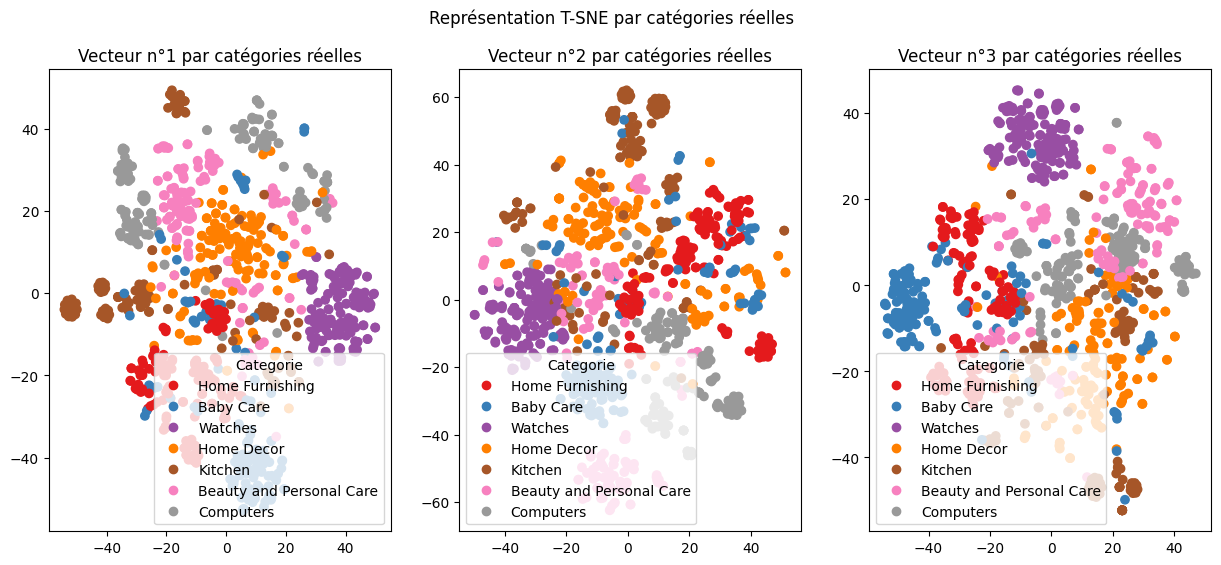

CPU times: user 33.9 s, sys: 40.1 ms, total: 33.9 s
Wall time: 8.33 s


In [67]:
%%time
fig = plt.figure(figsize=(15,6))
colors, labels= pd.factorize(data.category)
tsne_data = []
for i, vec in enumerate(pca_vectors):
    tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
    X_tsne = tsne.fit_transform(vec)
    tsne_data.append(X_tsne)
    ax = fig.add_subplot(1,3,i+1)
    scatter = ax.scatter(X_tsne[:,0],X_tsne[:,1], c=colors, cmap='Set1')
    ax.legend(handles=scatter.legend_elements()[0], labels=labels.to_list(), loc="best", title="Categorie")
    ax.set_title(f"Vecteur n°{i+1} par catégories réelles")

plt.suptitle("Représentation T-SNE par catégories réelles")
plt.show()

#### Latent Dirichlet Allocation (LDA)

In [68]:
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print("Topic {}:".format(topic_idx))
        print(" ".join([feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]))

no_top_words = 10

In [69]:
lda = LatentDirichletAllocation(n_components=7, max_iter=5, learning_method='online', learning_offset=50.,random_state=42)

In [70]:
%%time
lda_res = []
for i, item in enumerate(tf_idf_vectors):
    lda = LatentDirichletAllocation(n_components=7, max_iter=5, learning_method='online', learning_offset=50.,random_state=42)
    lda_vectors = lda.fit_transform(item.vect)
    lda_res.append((lda, item.features))

CPU times: user 2 s, sys: 2.84 ms, total: 2 s
Wall time: 2 s


In [71]:
for i, (lda, feature_names) in enumerate(lda_res):
    print(f"Topics : pour le corpus {i+1}")
    display_topics(lda, feature_names, no_top_words)
    print("---"*10)

Topics : pour le corpus 1
Topic 0:
rockmantra mug ceramic thrilling porcelain crafting permanent stay ensuring start
Topic 1:
bottle nutcase wrap sticker quirky water harness attitude playful designer
Topic 2:
cash shipping genuine delivery buy free product guarantee replacement day
Topic 3:
fast cut celebrity carbon pizza cutter wheel steel pack price
Topic 4:
mug coffee bring perfect design share smile ink selection broadcast
Topic 5:
baby girl cotton detail fabric dress print pack boy sleeve
Topic 6:
skin laptop warranty design shape eyelet polyester model print aroma
------------------------------
Topics : pour le corpus 2
Topic 0:
usb otg phone android fan smart enable jrb device power
Topic 1:
waiter pedrini corkscrew knife pfoa teflon bakelite steel italian spoon
Topic 2:
showpiece buddha stone combo showpiecebuy online handicraft exotic ganesha lal
Topic 3:
watch analog guarantee replacement day shipping genuine cash delivery free
Topic 4:
edp orignal avenue park believe lipsti

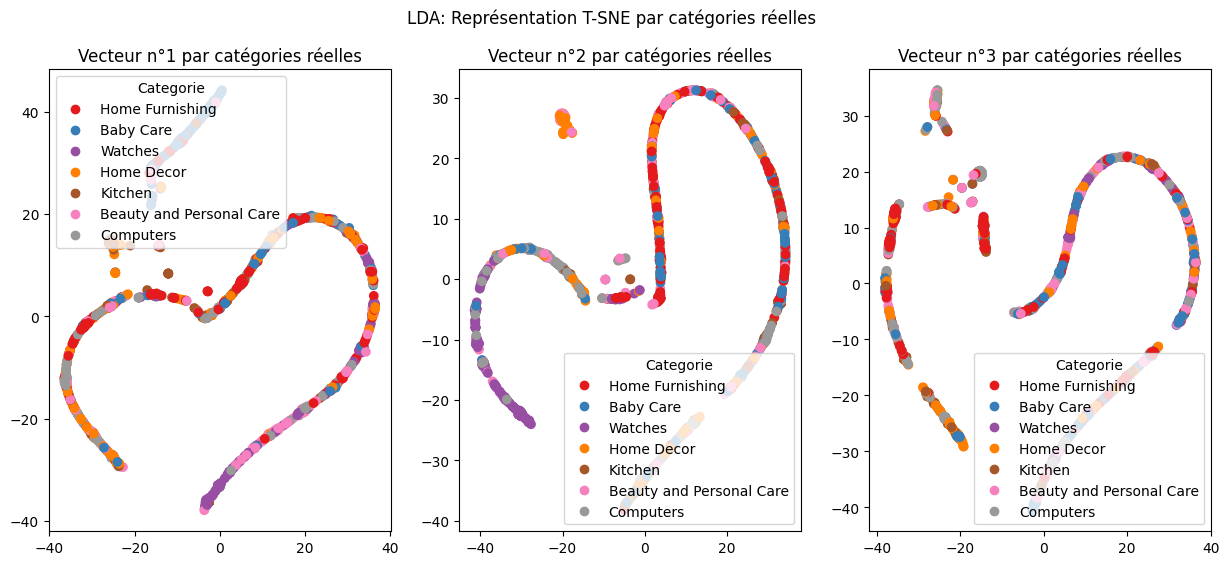

CPU times: user 24.7 s, sys: 24.8 ms, total: 24.7 s
Wall time: 6.96 s


In [72]:
%%time
fig = plt.figure(figsize=(15,6))
colors, labels= pd.factorize(data.category)
for i, (lda, _) in enumerate(lda_res):
    tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
    X = tsne.fit_transform(lda.transform(tf_idf_vectors[i].vect))
    ax = fig.add_subplot(1,3,i+1)
    scatter = ax.scatter(X[:,0],X[:,1], c=colors, cmap='Set1')
    ax.legend(handles=scatter.legend_elements()[0], labels=labels.to_list(), loc="best", title="Categorie")
    ax.set_title(f"Vecteur n°{i+1} par catégories réelles")

plt.suptitle("LDA: Représentation T-SNE par catégories réelles")
plt.show()

Les graphiques TSNE, ne montre pas une séparation appropriée.

Donc, en résumé, la méthode lda, ne nous permets pas de mieux séparer les catégories de produits.

In [73]:
lda_res

[(LatentDirichletAllocation(learning_method='online', learning_offset=50.0,
                            max_iter=5, n_components=7, random_state=42),
  array(['aaa', 'aapno', 'aari', ..., 'zoom', 'zora', 'zyxel'], dtype=object)),
 (LatentDirichletAllocation(learning_method='online', learning_offset=50.0,
                            max_iter=5, n_components=7, random_state=42),
  array(['aaa', 'aapno', 'aari', ..., 'zora', 'zyxel', 'zyxelbuy'],
        dtype=object)),
 (LatentDirichletAllocation(learning_method='online', learning_offset=50.0,
                            max_iter=5, n_components=7, random_state=42),
  array(['001', '005', '006', ..., 'zone', 'zora', 'zyxel'], dtype=object))]

#### K-means

ARI :  0.4218 time :  0.28


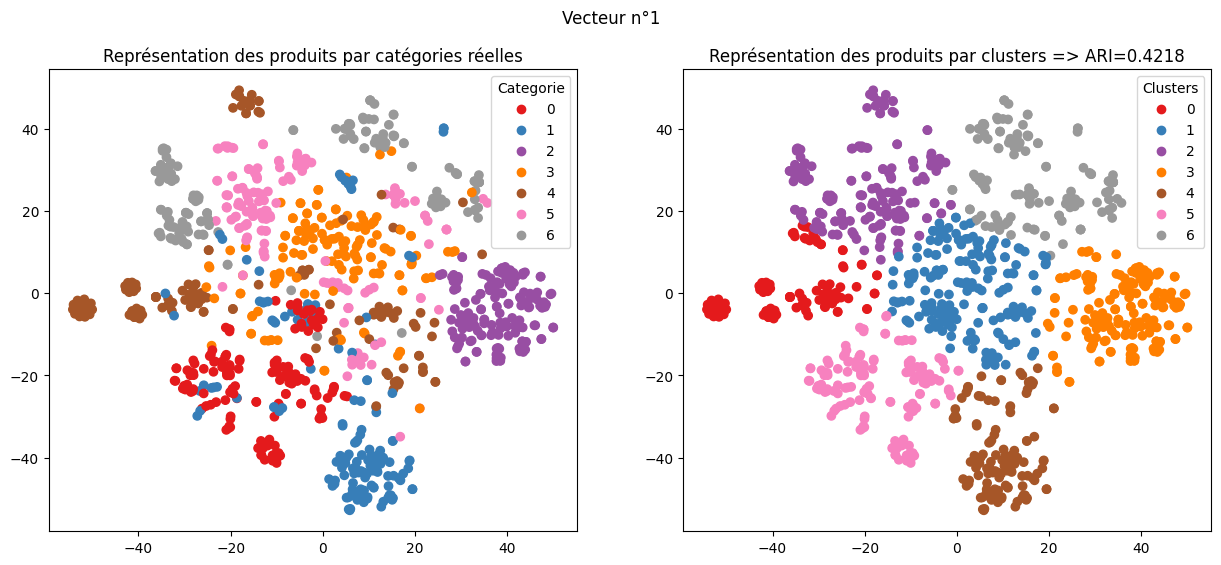

ARI :  0.3425 time :  0.27


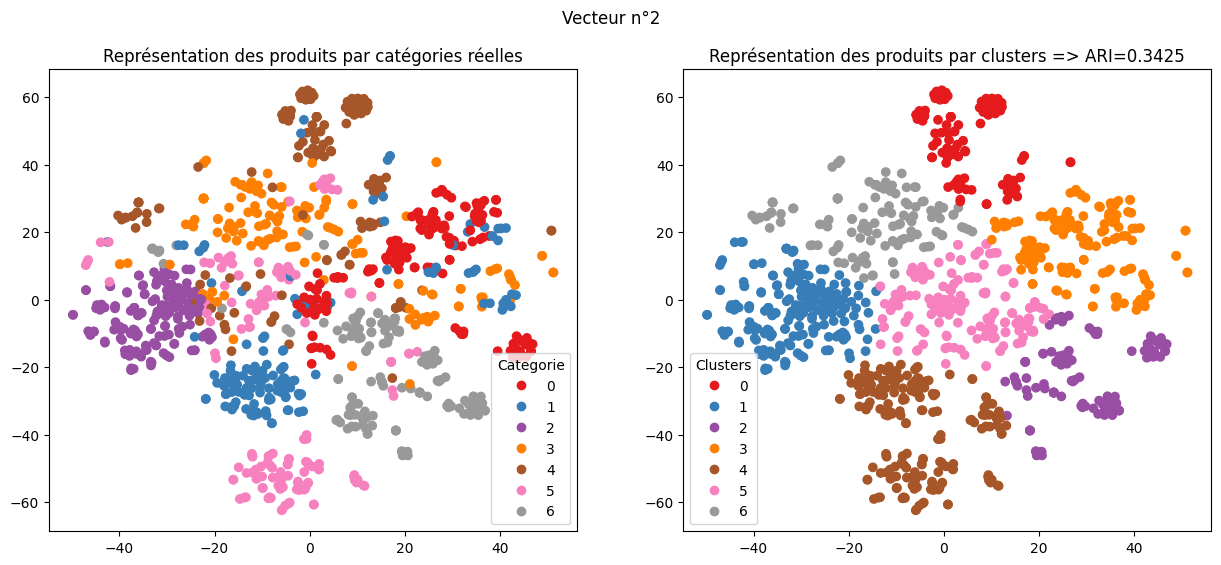

ARI :  0.3875 time :  0.3


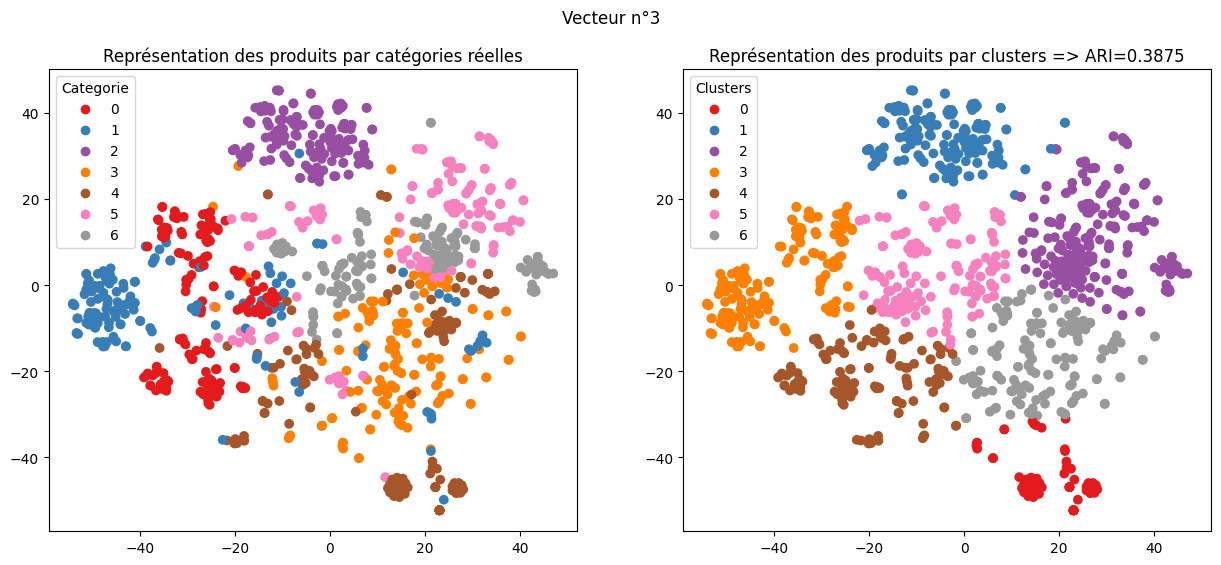

CPU times: user 4.04 s, sys: 125 ms, total: 4.16 s
Wall time: 1.72 s


In [74]:
%%time
# Détermination des clusters à partir des données après Tsne

k=7
y_cat_num, labels= pd.factorize(data.category)

cls = KMeans(n_clusters=k, n_init=100, random_state=42)
for i, X_tsne in enumerate(tsne_data):
    time1 = time.time()
    cls.fit(X_tsne)
    ARI = np.round(adjusted_rand_score(y_cat_num, cls.labels_),4)
    time2 = np.round(time.time() - time1, 2)
    print("ARI : ", ARI, "time : ", time2)
    tsne_visu_fct(X_tsne, y_cat_num, cls.labels_, ARI, f"Vecteur n°{i+1}")

Le résultat de notre algorithme k-means révèle que, pour les trois corpus étudiés, l’indice de Rand ajusté (ARI) se situe entre 0,4 et 0,54. Ce résultat quantitatif, associé à une visualisation graphique détaillée des catégories réelles, atteste de la faisabilité de classifier efficacement les biens de consommation en se fondant sur leur nom et/ou leur description.

## Images

### | SIFT

Nous allons prendre une image et appliquons la methode SIFT pour extraires les descripteurs

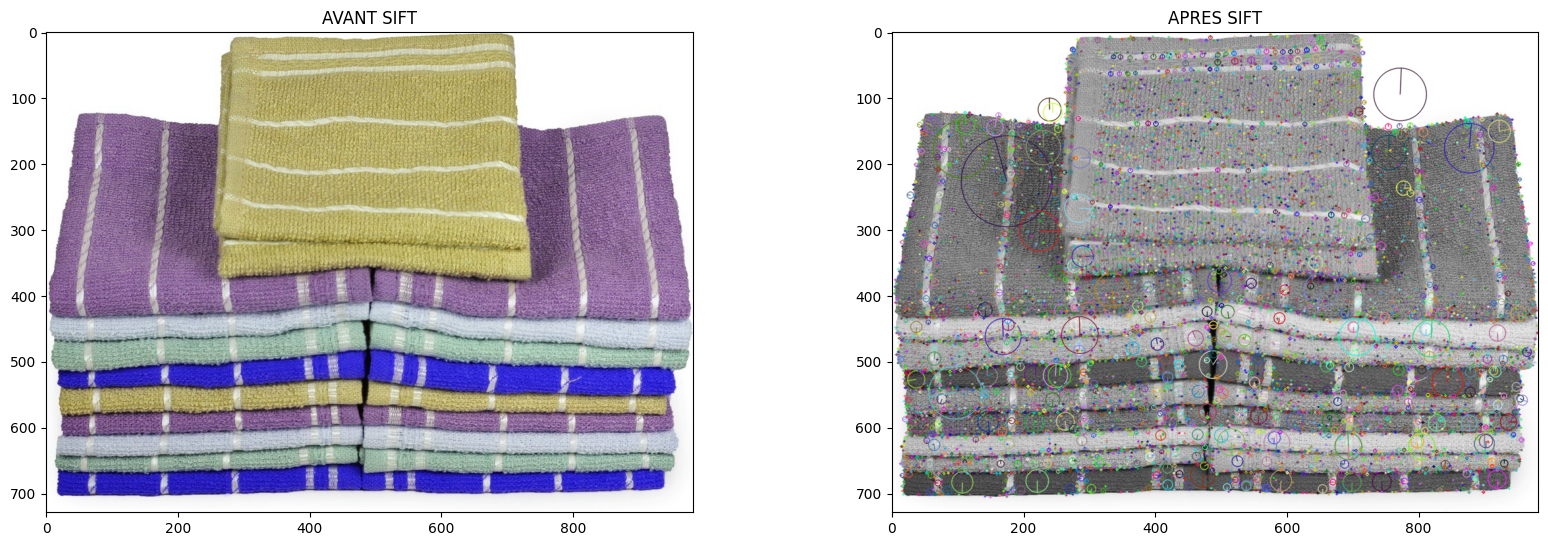

In [107]:
fig = plt.figure(figsize = (20, 6))

idx = data.iloc[2].uniq_id

image = cv.imread(path+"Images/"+idx+'.jpg')
cv.resize(image, (224, 224))

ax = fig.add_subplot(121)
ax.set_title("AVANT SIFT")
plt.imshow(image)

# Appliquer SIFT
sift = cv.SIFT_create()
gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY) # convert in gray

kp, des = sift.detectAndCompute(gray, None)
img=cv.drawKeypoints(gray, kp, image, flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

ax = fig.add_subplot(122)
plt.imshow(img)
ax.set_title("APRES SIFT")
plt.subplots_adjust(left=0.125, right=0.9, bottom=0.1, top=0.9, wspace=0.2, hspace=0.2)
plt.show()

#### Créations des descripteurs

In [77]:
sample_df = data.copy()
ids = sample_df.uniq_id.to_list()

In [91]:
%%time
descriptors_list = []
if os.path.exists(path+"all_descriptors.npy"):
    print("loading...")
    all_descriptors = np.load(path+"all_descriptors.npy")
    print("Descripteurs chargés depuis all_descriptors.npy")
else:
  sift = cv.SIFT_create()
  for product_id in ids:
      # Chargement de l'image
      img_path = f"{path}Images/{product_id}.jpg"
      image = cv.imread(img_path)

      # Conversion en niveaux de gris
      gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

      # Détection des keypoints et calcul des descripteurs SIFT
      keypoints, descriptors = sift.detectAndCompute(gray, None)
      if descriptors is not None:
          descriptors_list.append(descriptors)
      else:
          print(f"Aucun descripteur trouvé pour l'image : {img_path}")

  all_descriptors = np.vstack(descriptors_list)
  np.save(path+"all_descriptors.npy", all_descriptors)
  print("Descripteurs calculés et sauvegardés.")

print("Nombre de descripteurs : ", all_descriptors.shape)
print("---"*10)

loading...
Descripteurs chargés depuis all_descriptors.npy
Nombre de descripteurs :  (5977613, 128)
------------------------------
CPU times: user 21.5 ms, sys: 1.46 s, total: 1.48 s
Wall time: 3.1 s


In [79]:
all_descriptors[0]

array([  4.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,  11.,   0.,   0.,
         0.,   0.,   0.,   0.,   3.,   1.,   0.,   0.,   0.,   0.,   0.,
         0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,  90.,
         0.,   0.,   0.,   1.,   1.,   0.,  14., 174.,  10.,   0.,   1.,
         6.,   1.,   0.,  76.,  58.,   3.,   2.,  24.,  64.,   2.,   0.,
        22.,   8.,   0.,   1.,  17.,  29.,   0.,   0.,   2., 124.,   2.,
         0.,   0.,   1.,   0.,   0.,  22., 174.,  55.,   1.,   7.,  15.,
         0.,   0.,  37.,  96.,  25.,  29.,  98., 122.,   0.,   0.,   4.,
        31.,  11.,  21.,  32.,  21.,   0.,   0.,  13., 123.,   0.,   0.,
         1.,   0.,   0.,   0.,  52., 174.,   4.,   0.,   2.,  24.,   3.,
         1., 142.,  81.,  18.,  11.,  41., 174.,  24.,   1.,  18.,  94.,
        22.,   7.,   6.,   9.,   3.,   0.,  20.], dtype=float32)

#### Clustering des descripteurs

In [80]:
%%time

k = int(round(np.sqrt(len(all_descriptors)),0))
print("Nombre de clusters estimés : ", k)
print("Création de",k, "clusters de descripteurs ...")

# Clustering
kmeans = MiniBatchKMeans(n_clusters=k, random_state=42)
kmeans.fit(all_descriptors)
display(kmeans.labels_)

Nombre de clusters estimés :  2445
Création de 2445 clusters de descripteurs ...


array([1583, 1861,   46, ..., 1902, 1701, 1346], dtype=int32)

CPU times: user 4min 22s, sys: 658 ms, total: 4min 23s
Wall time: 1min 6s


#### Extraction des features images

In [ ]:
%%time

def build_histogram(descriptors, num_clusters):
    n_desc = descriptors.shape[0]

    # Récupéreation des labels correspondant aux descripteurs de cette image
    image_labels = labels[start_index:start_index + n_desc]

    # Calcul de l'histogramme pour cette image
    hist, _ = np.histogram(image_labels, bins=np.arange(num_clusters+1))

    # Normalisation
    #hist = hist.astype("float32")
    #hist /= (hist.sum() + 1e-7)

    return hist


start_index = 0
hist_vectors=[]
labels = kmeans.labels_
for image_desc in descriptors_list:
    hist = build_histogram(image_desc, k)
    hist_vectors.append(hist)
    start_index += image_desc.shape[0]

im_features = np.asarray(hist_vectors)
print("Fetaures image:", im_features.shape)
print("Histogramme pour la première image :", hist_vectors[0])
print("---"*10)

Fetaures image: (1049, 2445)
Histogramme pour la première image : [562  16   3 ... 265   8   6]
------------------------------
CPU times: user 120 ms, sys: 0 ns, total: 120 ms
Wall time: 119 ms


#### Classification des images: Kmeans

##### Réduction des dimensions

In [ ]:
%%time
# Réduction de dimension PCA
pca, X_pca = pca_dimensions(im_features, n=0.90)

# Réduction en deux dimensions via T-SNE
tsne = TSNE(n_components=2, perplexity=30, max_iter=2000, init='random', learning_rate=200, random_state=42)
X_tsne = tsne.fit_transform(X_pca)
tsne_sift_df = pd.DataFrame(X_tsne, columns=['tsne1', 'tsne2'])
tsne_sift_df['class'] = sample_df.category
tsne_sift_df['uniq_id'] = sample_df.uniq_id

CPU times: user 45.5 s, sys: 41.9 ms, total: 45.6 s
Wall time: 9.03 s


In [ ]:
tsne_sift_df.head()

,tsne1,tsne2,class,uniq_id
0,-69.193085,-0.977837,Home Furnishing,55b85ea15a1536d46b7190ad6fff8ce7
1,-69.775597,5.952357,Baby Care,7b72c92c2f6c40268628ec5f14c6d590
2,-44.248947,-4.265211,Baby Care,64d5d4a258243731dc7bbb1eef49ad74
3,-54.834034,9.181171,Home Furnishing,d4684dcdc759dd9cdf41504698d737d8
4,-69.614906,4.561482,Home Furnishing,6325b6870c54cd47be6ebfbffa620ec7


##### kmeans

In [ ]:
%%time
# Détermination des clusters à partir des données après Tsne
sample_df = sample_df.loc[sample_df.uniq_id!="9743e6d1c9f3180483825fe4d2e97836"]
k=7
y_cat_num, labels= pd.factorize(tsne_sift_df['class'])

cls = KMeans(n_clusters=k, random_state=42)
time1 = time.time()
cls.fit(X_tsne)
ARI = np.round(adjusted_rand_score(y_cat_num, cls.labels_), 4)
time2 = np.round(time.time() - time1, 2)
print("ARI : ", ARI, "time : ", time2)
tsne_sift_df['cluster'] = cls.labels_

ARI :  0.0419 time :  0.01
CPU times: user 20.8 ms, sys: 0 ns, total: 20.8 ms
Wall time: 10.7 ms


In [ ]:
tsne_sift_df.head()

,tsne1,tsne2,class,uniq_id,cluster
0,-69.193085,-0.977837,Home Furnishing,55b85ea15a1536d46b7190ad6fff8ce7,1
1,-69.775597,5.952357,Baby Care,7b72c92c2f6c40268628ec5f14c6d590,1
2,-44.248947,-4.265211,Baby Care,64d5d4a258243731dc7bbb1eef49ad74,1
3,-54.834034,9.181171,Home Furnishing,d4684dcdc759dd9cdf41504698d737d8,1
4,-69.614906,4.561482,Home Furnishing,6325b6870c54cd47be6ebfbffa620ec7,1


##### Visualisation des clusters T-SNE

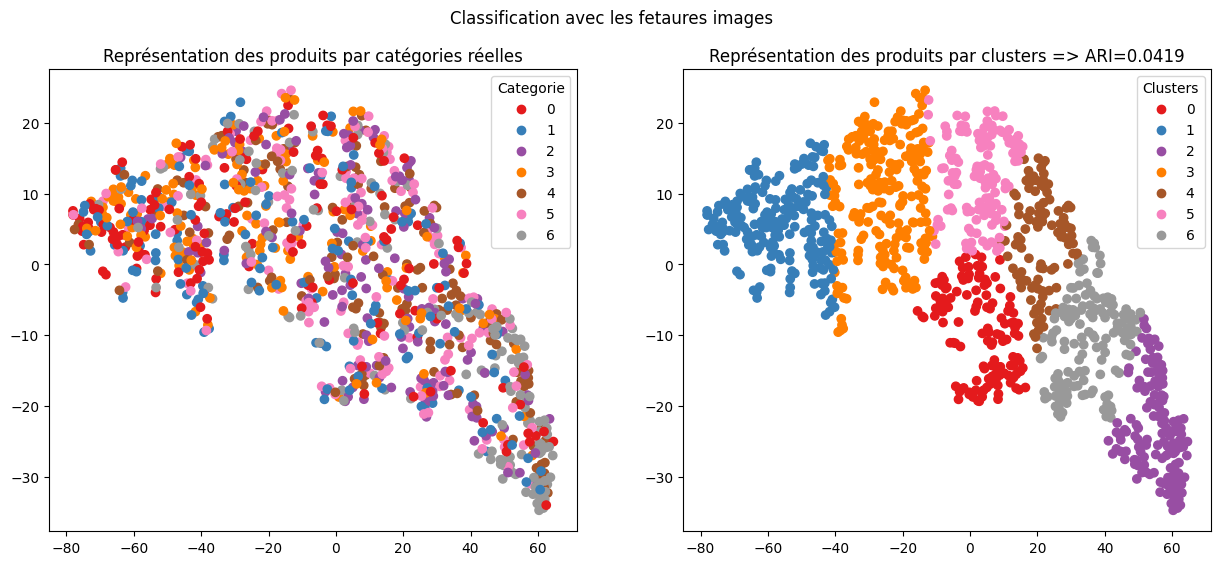

In [ ]:
tsne_visu_fct(X_tsne, y_cat_num, cls.labels_, ARI, "Classification avec les fetaures images")

In [ ]:
tsne_sift_df.groupby("cluster")["class"].value_counts().to_frame().reset_index()

,cluster,class,count
0,0,Watches,30
1,0,Beauty and Personal Care,27
2,0,Kitchen,23
3,0,Baby Care,17
4,0,Computers,11
5,0,Home Furnishing,10
6,0,Home Decor,8
7,1,Home Furnishing,54
8,1,Home Decor,52
9,1,Baby Care,44


In [ ]:
from sklearn import metrics
conf_mat = metrics.confusion_matrix(y_cat_num, cls.labels_)
print(conf_mat)

[[10 54 12 32 13 19 10]
 [17 44 13 26 12 16 21]
 [30  8 12 21 23 22 34]
 [ 8 52  4 49 10 16 11]
 [23 15 21 30 21 14 26]
 [27 16 13 32 15 23 24]
 [11 10 63 23 10 13 20]]


In [ ]:
print(metrics.classification_report(y_cat_num, cls.labels_))

              precision    recall  f1-score   support

           0       0.08      0.07      0.07       150
           1       0.22      0.30      0.25       149
           2       0.09      0.08      0.08       150
           3       0.23      0.33      0.27       150
           4       0.20      0.14      0.17       150
           5       0.19      0.15      0.17       150
           6       0.14      0.13      0.14       150

    accuracy                           0.17      1049
   macro avg       0.16      0.17      0.16      1049
weighted avg       0.16      0.17      0.16      1049



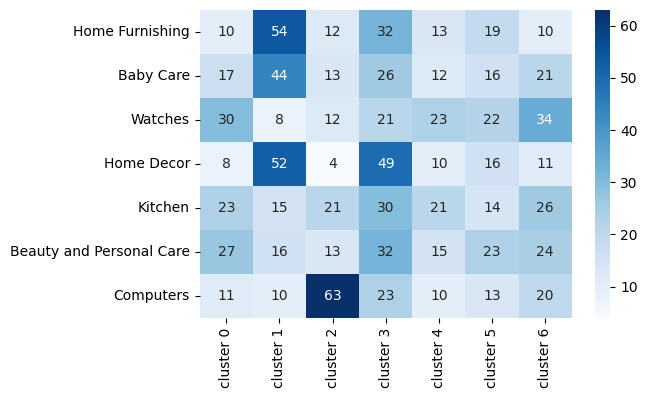

In [ ]:
df_cm = pd.DataFrame(conf_mat, index = labels,
                  columns = [f"cluster {i}" for i in  np.unique(cls.labels_)])
plt.figure(figsize = (6,4))
sns.heatmap(df_cm, annot=True, cmap="Blues")
plt.show()

In [ ]:
ids = tsne_sift_df.loc[(tsne_sift_df['class']=='Kitchen') & (tsne_sift_df.cluster==6)].index.to_list()
ids = tsne_sift_df.loc[(tsne_sift_df.cluster==6)].index.to_list()
"""for id in ids:
    tsne_sift_df.iloc[id]
    im_id = tsne_sift_df.iloc[id].uniq_id
    fig = plt.figure(figsize = (8, 5))
    filename = f"{path}Images/{im_id}.jpg"
    image = imread(filename)
    plt.imshow(image)
plt.show()"""

'for id in ids:\n    tsne_sift_df.iloc[id]\n    im_id = tsne_sift_df.iloc[id].uniq_id\n    fig = plt.figure(figsize = (8, 5))\n    filename = f"{path}Images/{im_id}.jpg"\n    image = imread(filename)\n    plt.imshow(image)\nplt.show()'

In [ ]:
data.to_csv(f"{path}cleaned_data.csv", index=False)

In [ ]:
end_time = time.time()
print(f"Execution time={end_time-init_time} seconds")

Execution time=1872.710083246231 seconds
